# EDA ③ 방위사업청 국산화개발품목 (B2, `15119899`) — 1만 건 요건 데이터 ②

산출물 4 「전처리 및 EDA 보고서」 중 국산화 편

| 항목 | 내용 |
|---|---|
| 원본 | `data/raw/dapa/dapa_localized_items_20260509.csv` (cp949, 10열, 33,965행) |
| 정제본 | RDS `clean_dapa_localized_item` (25,025행) — 이 노트북은 같은 규칙을 원본에서 재현해 값이 일치함을 §2에서 확인한다 |
| 정제 규칙 | `docs/reference/data-cleaning-rules.md` §2 |
| 1만 건 요건 | 관세청 수출입 294,420행과 함께 **2종 중 하나**. 원본 33,965행 기준 |
| 전자 판정 | `fsc2 IN (58, 59, 60)`. 60에 해당하는 행은 0개 |

**해석 경계**

- 국산화개발품목 **건수는 국산화율이 아니다**. 이 노트북은 「율」을 계산하지 않는다.
- **28개 사업(대부분 지상 장비, 헬기 · 초계기 4개 사업 포함)의 2023-08 등록 목록(기준일 미표기)**이다. `최종수정일`은 레코드 갱신일이며 개발 완료 시점이 아니고 27%만 채워져 있다 → 연도 축 해석을 하지 않는다.
- 규모는 항상 **원본 33,965행 / 업무키 고유 25,025행 / 부품관리번호 고유 12,788개**를 나란히 쓴다. 33,965만 단독으로 말하지 않는다.
- 군급분류(FSC)는 이 노트북 안에서만 쓰는 축이다. **관세청 HS와 어떤 수준에서도 엮지 않는다**(HS ↔ FSC 카테고리 맵을 쓰지 않는다).
- `계약업체`는 법인명이며 개인정보가 아니다. 업체명은 **국산 제조의 증거가 아니라** 개발 참여 기록이다.

목차: 1 적재·점검 → 2 전처리(중복·FSC·전자 판정) → 3 기술통계 → 4 추세(갱신일) → 5 비교(사업) → 6 구성(군급) → 7 관계 → 8 공간(업체 소재지) → 9 차이검정 → 10 상관분석 → 11 요약·한계

In [1]:
import platform, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = Path.cwd() if (Path.cwd() / "scripts").exists() else Path.cwd().parent
RAW = ROOT / "data/raw/dapa"
REF = ROOT / "data" / "reference"

plt.rcParams["font.family"] = {"Darwin": "AppleGothic", "Windows": "Malgun Gothic"}.get(platform.system(), "NanumGothic")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30, "display.width", 180, "display.float_format", "{:,.2f}".format)

ELEC_FSG = ("58", "59", "60")          # 전자 판정 기준(FSG 58·59·60). 60 해당 행은 0개
SEMI_FSC4 = ("5961", "5962")           # 반도체 소자 · 집적회로
C_ELEC, C_OTHER = "#2a6fdb", "#b0b0b0"
C_MAIN, C_SUB = "#2a6fdb", "#e07b39"

## 1. 적재·기본 점검

원본은 **수정하지 않고** 읽기만 한다. 모든 열을 문자열로 읽어 코드 앞자리 0이 사라지지 않게 한다.

In [2]:
SRC = RAW / "dapa_localized_items_20260509.csv"
raw = pd.read_csv(SRC, encoding="cp949", dtype=str)

print(f"원본: {len(raw):,}행 × {raw.shape[1]}열   ({SRC.name}, cp949)")
print("열:", list(raw.columns))
print(f"완전 중복 행: {raw.duplicated().sum():,}")
print(f"업무키(사업명 × 부품관리번호) 고유: {len(raw.drop_duplicates(['사업명', '부품관리번호'])):,}")
print(f"사업 {raw.사업명.nunique()}개 · 부품관리번호 고유 {raw.부품관리번호.nunique():,} · 재고번호(NSN) 고유 {raw.재고번호.nunique():,}")
raw.head(3)

원본: 33,965행 × 10열   (dapa_localized_items_20260509.csv, cp949)
열: ['사업명', '부품관리번호', '재고번호', '군급분류', '품명', '도면번호', '도면부품번호', '규격번호', '계약업체', '최종수정일']
완전 중복 행: 8,940
업무키(사업명 × 부품관리번호) 고유: 25,025
사업 28개 · 부품관리번호 고유 12,788 · 재고번호(NSN) 고유 12,777


,사업명,부품관리번호,재고번호,군급분류,품명,도면번호,도면부품번호,규격번호,계약업체,최종수정일
0,K-2 전차,M00043959,375017476,5340,"멈치,완충용",60702464,60702464,NaN,덕인산업,2021-07-08
1,K-2 전차,M00043960,375018648,3120,"부싱,슬리브형",60702507,60702507,NaN,주식회사 천명하이텍,NaN
2,K-2 전차,M00043962,375019231,5315,"핀,직선형,유두형",60702512,60702512,NaN,건웅테크 주식회사,NaN


### 1-2. 열별 결측·고유 값

`규격번호`·`최종수정일`처럼 대부분 비어 있는 열은 분석 축으로 쓰지 않는다. 결측은 **판정하고 남긴다** — 채우거나 지우지 않는다.

In [3]:
na = pd.DataFrame({
    "결측 수": raw.isna().sum(),
    "결측률": raw.isna().mean(),
    "고유 값 수": raw.nunique(),
    "예시": [raw[c].dropna().iloc[0] if raw[c].notna().any() else "" for c in raw.columns],
})
na.style.format({"결측 수": "{:,}", "결측률": "{:.1%}", "고유 값 수": "{:,}"})

,결측 수,결측률,고유 값 수,예시
사업명,0,0.0%,28,K-2 전차
부품관리번호,0,0.0%,"12,788",M00043959
재고번호,12,0.0%,"12,777",375017476
군급분류,1,0.0%,243,5340
품명,35,0.1%,"3,435","멈치,완충용"
도면번호,"4,414",13.0%,"10,788",60702464
도면부품번호,"4,414",13.0%,"11,912",60702464
규격번호,"29,890",88.0%,282,KS B 1324
계약업체,123,0.4%,407,덕인산업
최종수정일,"25,191",74.2%,2,2021-07-08


## 2. 전처리 — 중복·FSC·전자 판정

정제본(`clean_dapa_localized_item`)과 **같은 규칙**을 원본에서 재현한다. 절 끝에서 행 수·전자군 수가 정제본 기대값과 같은지 확인한다(DB 접속 없이 대조할 수 있게 기대값을 코드에 적어 둔다).

In [4]:
# ① 완전 중복 제거가 업무키(사업명 × 부품관리번호) 중복 제거와 같은 결과인지 먼저 확인
n_full = len(raw.drop_duplicates())
n_key = len(raw.drop_duplicates(["사업명", "부품관리번호"]))
print(f"완전 중복 제거 후 {n_full:,} / 업무키 중복 제거 후 {n_key:,} → "
      f"{'같다(업무키 충돌 없음)' if n_full == n_key else '다르다(업무키 충돌 — 기록 필요)'}")

dup = raw.groupby(["사업명", "부품관리번호"]).size().rename("중복수")
b2 = raw.drop_duplicates(["사업명", "부품관리번호"]).copy()
b2 = b2.merge(dup, left_on=["사업명", "부품관리번호"], right_index=True, how="left")
print(f"중복수 분포: {b2.중복수.value_counts().sort_index().to_dict()}")

# ② FSC 4자리 정리 — 4자리가 아닌 값은 군급 축 집계에서 뺀다(지우지 않고 사유를 남긴다)
g = b2.군급분류.fillna("").str.strip()
b2["fsc4"] = np.where(g.str.len() == 4, g, np.nan)
b2["fsc2"] = pd.Series(b2.fsc4, index=b2.index).str[:2]
bad = b2[b2.fsc4.isna()]
print(f"\nFSC가 4자리가 아닌 행: {len(bad)}개 → 군급 축에서 제외. "
      f"원값 분포: {bad.군급분류.fillna('(결측)').value_counts().to_dict()}")

# ③ 전자 판정 (FSG 58·59·60) — 속성일 뿐 필터가 아니다
b2["전자군"] = b2.fsc2.isin(ELEC_FSG)
b2["반도체군"] = b2.fsc4.isin(SEMI_FSC4)

# ④ 업체명 — DB 정제본은 별도 정규화 규칙을 쓴다. 여기서는 공백 · 법인 접두어만 떼고 원문 고유 수도 함께 본다
b2["업체_정규"] = (b2.계약업체.fillna("(미기재)").str.replace(r"\s+", "", regex=True)
                          .str.replace(r"^\(주\)|\(주\)$|^주식회사|주식회사$|^㈜|㈜$", "", regex=True))

print(f"\n업무키 고유 {len(b2):,}행 · 전자군 {int(b2.전자군.sum()):,}행 · 반도체군(5961·5962) {int(b2.반도체군.sum()):,}행")
print(f"업체 고유: 원문 {b2.계약업체.nunique():,} → 간단 정규화 {b2.업체_정규.nunique():,} "
      f"(DB 정제본 contractor_name_norm 기준은 403)")
print(f"정제본 기대값 대조 — 25,025행 / 전자군 2,717행: "
      f"{'일치' if (len(b2), int(b2.전자군.sum())) == (25025, 2717) else '불일치(확인 필요)'}")

완전 중복 제거 후 25,025 / 업무키 중복 제거 후 25,025 → 같다(업무키 충돌 없음)
중복수 분포: {1: 20703, 2: 2997, 3: 498, 4: 396, 5: 144, 6: 51, 7: 47, 8: 32, 9: 23, 10: 20, 11: 14, 12: 17, 13: 14, 14: 9, 15: 9, 16: 4, 17: 7, 18: 5, 19: 1, 20: 3, 21: 4, 22: 2, 23: 1, 25: 2, 26: 2, 27: 3, 28: 2, 31: 1, 33: 1, 35: 3, 36: 2, 37: 1, 43: 1, 47: 1, 48: 1, 49: 1, 52: 1, 55: 1, 57: 1}

FSC가 4자리가 아닌 행: 16개 → 군급 축에서 제외. 원값 분포: {'0': 15, '(결측)': 1}

업무키 고유 25,025행 · 전자군 2,717행 · 반도체군(5961·5962) 67행
업체 고유: 원문 407 → 간단 정규화 404 (DB 정제본 contractor_name_norm 기준은 403)
정제본 기대값 대조 — 25,025행 / 전자군 2,717행: 일치


### 2-2. 보고 5단계 (`data-cleaning-rules.md` §4 양식)

In [5]:
stage = pd.DataFrame({
    "단계": ["① 원본 전체", "② 완전 중복 제거(업무키 고유)", "③ FSC 4자리 유효",
             "④ 전자 계열 후보(FSG 58·59·60)", "⑤ 반도체군(FSC 5961·5962)"],
    "행 수": [len(raw), len(b2), int(b2.fsc4.notna().sum()), int(b2.전자군.sum()), int(b2.반도체군.sum())],
    "사업 수": [raw.사업명.nunique(), b2.사업명.nunique(), b2[b2.fsc4.notna()].사업명.nunique(),
               b2[b2.전자군].사업명.nunique(), b2[b2.반도체군].사업명.nunique()],
    "업체 수": [raw.계약업체.nunique(), b2.계약업체.nunique(), b2[b2.fsc4.notna()].계약업체.nunique(),
               b2[b2.전자군].계약업체.nunique(), b2[b2.반도체군].계약업체.nunique()],
})
stage["원본 대비"] = stage["행 수"] / len(raw)
stage.style.format({"행 수": "{:,}", "원본 대비": "{:.1%}"}).hide(axis="index")

단계,행 수,사업 수,업체 수,원본 대비
① 원본 전체,"33,965",28,407,100.0%
② 완전 중복 제거(업무키 고유),"25,025",28,407,73.7%
③ FSC 4자리 유효,"25,009",28,406,73.6%
④ 전자 계열 후보(FSG 58·59·60),"2,717",25,98,8.0%
⑤ 반도체군(FSC 5961·5962),67,10,22,0.2%


## 3. 기술통계

세 단위(사업 · 군급 FSC4 · 업체)로 부품 수 분포를 본다. 어느 단위든 소수가 대부분을 차지하는지가 핵심이다.

In [6]:
units = {"사업(28개)": b2.사업명, "군급 FSC4": b2.fsc4.dropna(), "업체(정규화)": b2.업체_정규}
desc = {}
for k, s in units.items():
    cnt = s.value_counts()
    desc[k] = {"그룹 수": len(cnt), "합계 부품": int(cnt.sum()), "평균": cnt.mean(), "중앙값": cnt.median(),
               "최대": int(cnt.max()), "왜도": stats.skew(cnt.values),
               "상위 5개 점유율": cnt.nlargest(5).sum() / cnt.sum()}
d3 = pd.DataFrame(desc).T
d3.style.format({"그룹 수": "{:,.0f}", "합계 부품": "{:,.0f}", "평균": "{:,.1f}", "중앙값": "{:,.1f}",
                 "최대": "{:,.0f}", "왜도": "{:.2f}", "상위 5개 점유율": "{:.1%}"})

,그룹 수,합계 부품,평균,중앙값,최대,왜도,상위 5개 점유율
사업(28개),28,"25,025",893.8,542.0,"2,838",0.78,49.7%
군급 FSC4,242,"25,009",103.3,12.5,"3,281",6.56,31.9%
업체(정규화),404,"25,025",61.9,6.0,"2,676",7.51,40.3%


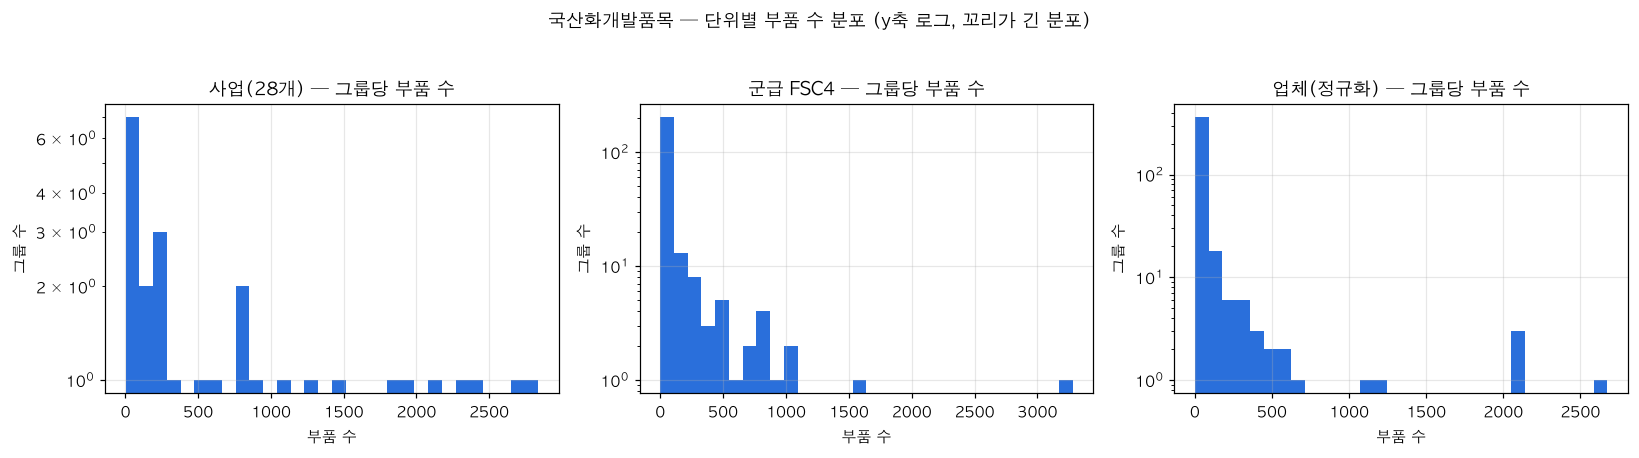

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, (k, s) in enumerate(units.items()):
    cnt = s.value_counts()
    ax[i].hist(cnt.values, bins=30, color=C_MAIN)
    ax[i].set(title=f"{k} — 그룹당 부품 수", xlabel="부품 수", ylabel="그룹 수", yscale="log")
    ax[i].grid(alpha=.3)
plt.suptitle("국산화개발품목 — 단위별 부품 수 분포 (y축 로그, 꼬리가 긴 분포)", y=1.03)
plt.tight_layout(); plt.show()

## 4. 추세 — `최종수정일` (해석 주의)

**이 절은 추세로 읽지 않는다.** `최종수정일`은 개발 완료 시점이 아니라 레코드 갱신일이고, 채워진 값은 모두 한 해에 몰려 있으며 나머지는 결측이다. 시각화 5종 중 「추세」축이 이 데이터에 **없다는 사실 자체**를 확인하는 절이다.

최종수정일 있음 6,865행(27.4%) / 결측 18,160행
채워진 값의 연도: [2021] → 연도 축 비교가 불가능하다(사건 연도가 아니라 갱신일, 한 해에만 존재)


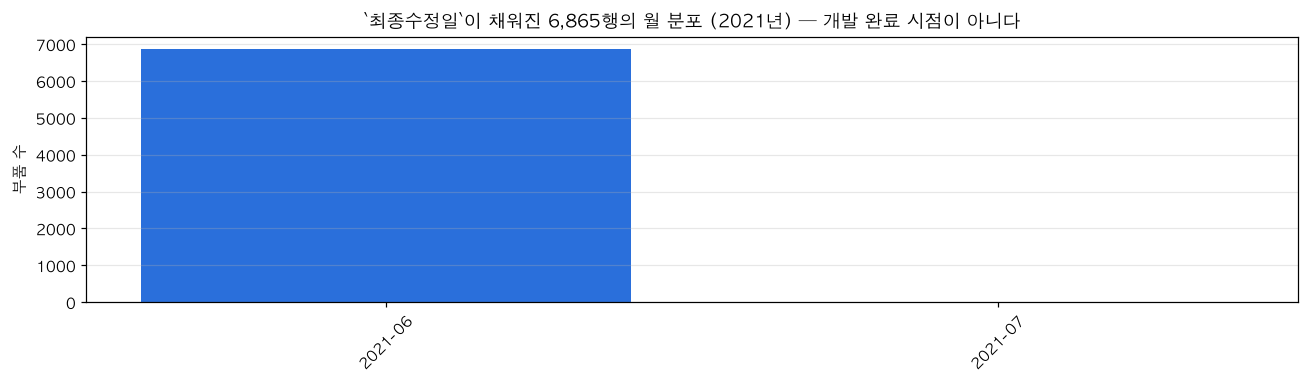


전자군 여부별 최종수정일 채움 비율 — 결측이 한쪽에 쏠렸는지 확인:


,비전자,전자군
최종수정일 결측,71.3%,82.6%
최종수정일 있음,28.7%,17.4%


In [8]:
dt = pd.to_datetime(b2.최종수정일, errors="coerce")
years = sorted(dt.dt.year.dropna().unique().astype(int).tolist())
print(f"최종수정일 있음 {dt.notna().sum():,}행({dt.notna().mean():.1%}) / 결측 {dt.isna().sum():,}행")
print(f"채워진 값의 연도: {years} → 연도 축 비교가 불가능하다(사건 연도가 아니라 갱신일, 한 해에만 존재)")

mon = dt.dropna().dt.to_period("M").value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.bar([str(p) for p in mon.index], mon.values, color=C_MAIN)
ax.set(title=f"`최종수정일`이 채워진 {dt.notna().sum():,}행의 월 분포 ({years[0]}년) — 개발 완료 시점이 아니다",
       ylabel="부품 수")
ax.tick_params(axis="x", rotation=45); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

fill = pd.crosstab(dt.notna(), b2.전자군, normalize="columns")
fill.index = ["최종수정일 결측", "최종수정일 있음"]
fill.columns = ["비전자", "전자군"]
print("\n전자군 여부별 최종수정일 채움 비율 — 결측이 한쪽에 쏠렸는지 확인:")
fill.style.format("{:.1%}")

## 5. 비교 — 사업 28개별 부품 수 (전자 / 비전자)

사업은 28개이고 **대부분 지상 기동·화력 계열**이다. 헬기 3개 · 해상초계기 1개 사업이 들어 있고, 함정 · 유도무기 사업은 없다.

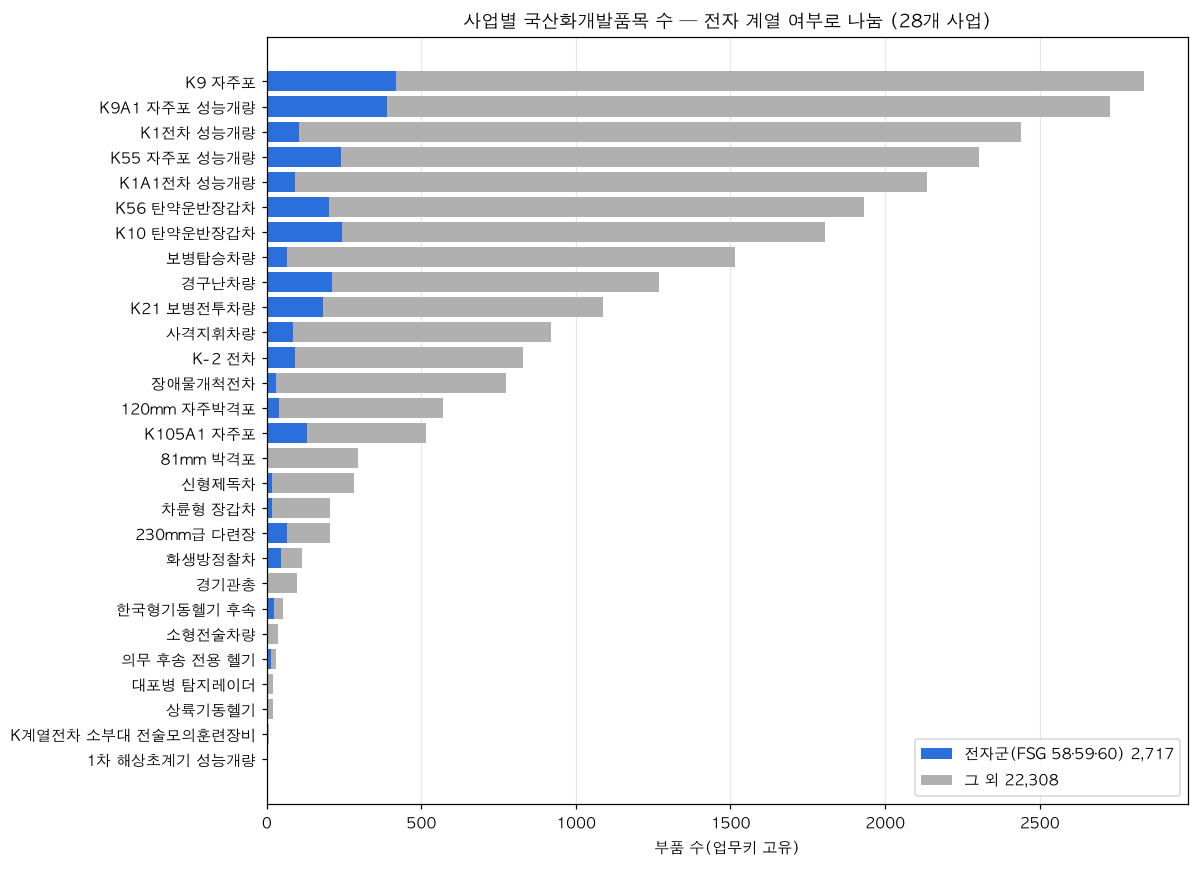

전자군,전자군,비전자,합계,전자 비중
사업명,,,,
K9 자주포,417,"2,421","2,838",14.7%
K9A1 자주포 성능개량,388,"2,338","2,726",14.2%
K1전차 성능개량,105,"2,334","2,439",4.3%
K55 자주포 성능개량,239,"2,065","2,304",10.4%
K1A1전차 성능개량,93,"2,043","2,136",4.4%
K56 탄약운반장갑차,201,"1,730","1,931",10.4%
K10 탄약운반장갑차,245,"1,562","1,807",13.6%
보병탑승차량,67,"1,447","1,514",4.4%
경구난차량,210,"1,059","1,269",16.5%


In [9]:
piv = pd.crosstab(b2.사업명, b2.전자군).rename(columns={False: "비전자", True: "전자군"})
piv = piv.reindex(columns=["전자군", "비전자"], fill_value=0)
piv["합계"] = piv.sum(axis=1)
piv["전자 비중"] = piv["전자군"] / piv["합계"]
piv = piv.sort_values("합계")

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(piv.index, piv["전자군"], color=C_ELEC, label=f"전자군(FSG 58·59·60) {int(piv['전자군'].sum()):,}")
ax.barh(piv.index, piv["비전자"], left=piv["전자군"], color=C_OTHER, label=f"그 외 {int(piv['비전자'].sum()):,}")
ax.set(xlabel="부품 수(업무키 고유)", title="사업별 국산화개발품목 수 — 전자 계열 여부로 나눔 (28개 사업)")
ax.legend(loc="lower right"); ax.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.show()

piv.sort_values("합계", ascending=False).style.format(
    {"전자군": "{:,}", "비전자": "{:,}", "합계": "{:,}", "전자 비중": "{:.1%}"})

## 6. 구성 — 군급분류(FSG 2자리) 구성과 사업 × 군급 히트맵

FSG 국문명은 `data/reference/fsg_master.csv`를 쓴다. **여기서 나오는 편중 자체가 메시지다** — 체결구류·전선은 많고 반도체군은 거의 없다.

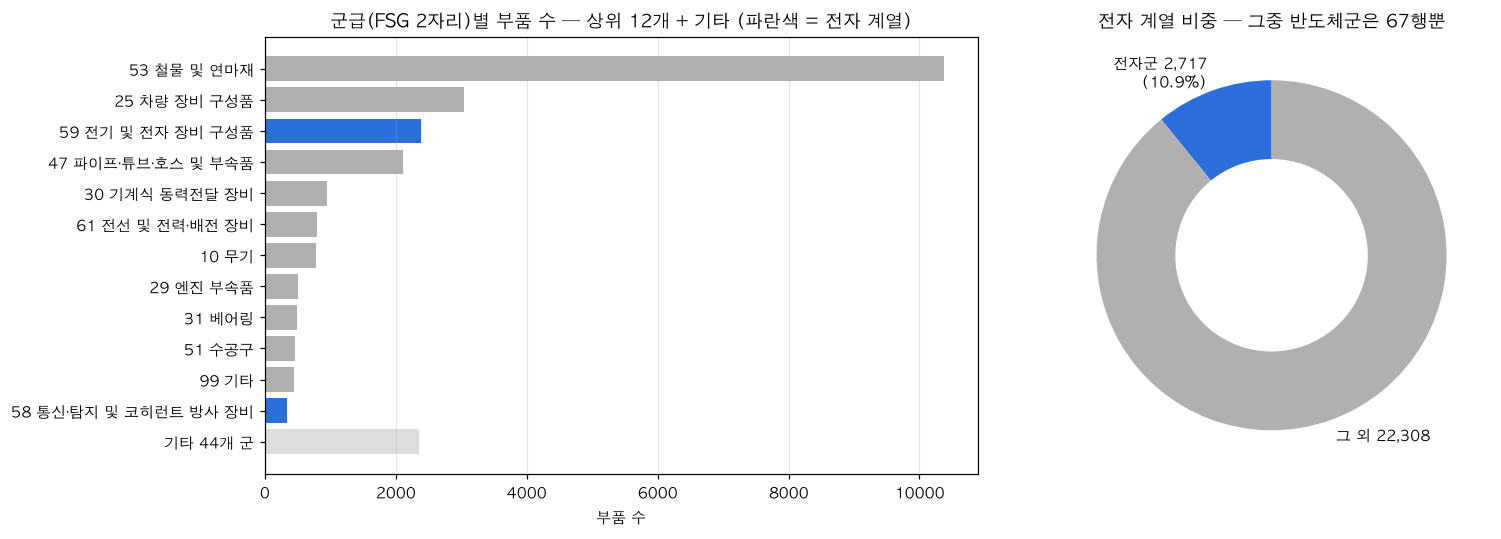

반도체군(FSC 5961, 5962): 업무키 고유 67행 / 원본 기준 83행 — 「반도체군 국산화 근거는 거의 없다」는 결론의 근거. 근거 없음이 아니라 근거 있는 빈칸으로 읽는다.


In [10]:
fsg = pd.read_csv(REF / "fsg_master.csv", dtype={"fsg_code": str})
fsg_ko = dict(zip(fsg.fsg_code.str.zfill(2), fsg.fsg_name_ko))

c2 = b2.dropna(subset=["fsc2"]).fsc2.value_counts()
TOPN = 12
lab = [f"{k} {fsg_ko.get(k, '(미등재)')}" for k in c2.index]
show = pd.Series(c2.values[:TOPN], index=lab[:TOPN])
show[f"기타 {len(c2) - TOPN}개 군"] = c2.values[TOPN:].sum()
colors = [C_ELEC if k in ELEC_FSG else C_OTHER for k in c2.index[:TOPN]] + ["#dddddd"]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].barh(list(show.index)[::-1], list(show.values)[::-1], color=colors[::-1])
ax[0].set(title=f"군급(FSG 2자리)별 부품 수 — 상위 {TOPN}개 + 기타 (파란색 = 전자 계열)", xlabel="부품 수")
ax[0].grid(axis="x", alpha=.3)

n_elec, n_other = int(b2.전자군.sum()), int((~b2.전자군).sum())
ax[1].pie([n_elec, n_other],
          labels=[f"전자군 {n_elec:,}\n({n_elec / len(b2):.1%})", f"그 외 {n_other:,}"],
          colors=[C_ELEC, C_OTHER], startangle=90, wedgeprops=dict(width=.45))
ax[1].set(title=f"전자 계열 비중 — 그중 반도체군은 {int(b2.반도체군.sum()):,}행뿐")
plt.tight_layout(); plt.show()

raw_semi = int(raw.군급분류.fillna("").str[:4].isin(SEMI_FSC4).sum())
print(f"반도체군(FSC {', '.join(SEMI_FSC4)}): 업무키 고유 {int(b2.반도체군.sum())}행 / 원본 기준 {raw_semi}행 "
      "— 「반도체군 국산화 근거는 거의 없다」는 결론의 근거. 근거 없음이 아니라 근거 있는 빈칸으로 읽는다.")

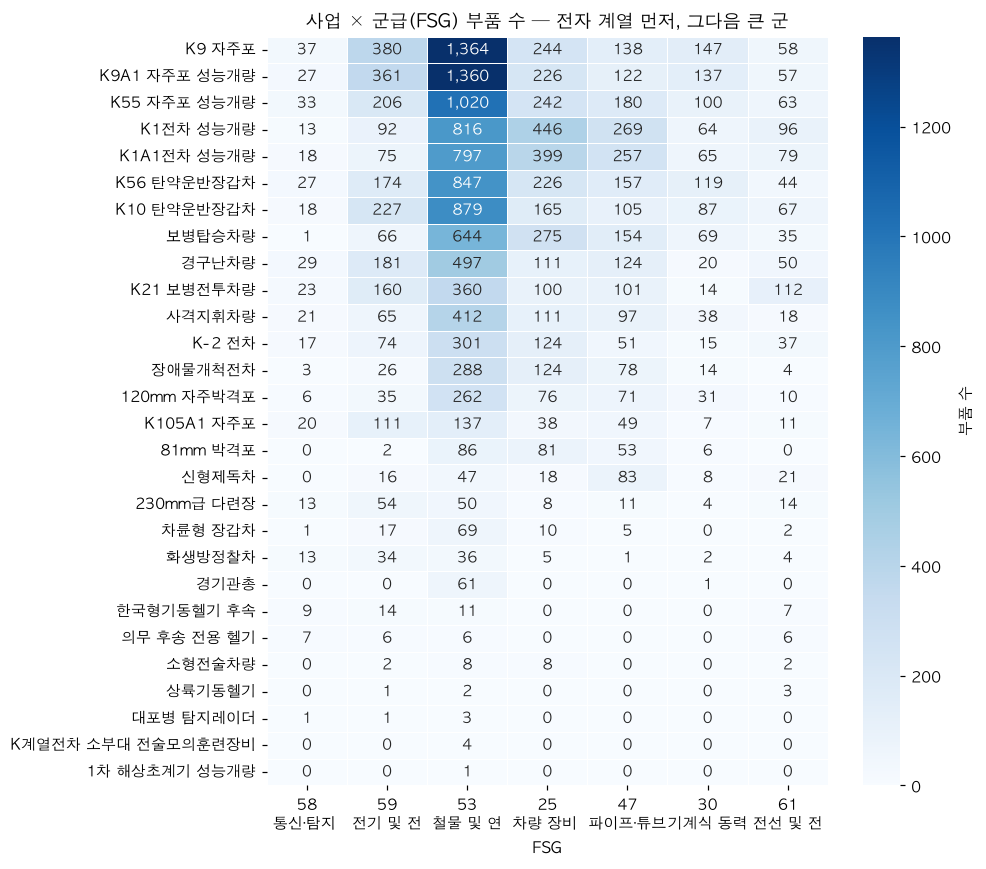

In [11]:
keep = [k for k in ELEC_FSG if k in set(b2.fsc2.dropna())] + [k for k in c2.index[:6] if k not in ELEC_FSG]
h = (b2[b2.fsc2.isin(keep)].pivot_table(index="사업명", columns="fsc2", values="부품관리번호", aggfunc="count")
       .reindex(columns=keep).fillna(0))
h = h.loc[h.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(h, annot=True, fmt=",.0f", cmap="Blues", cbar_kws={"label": "부품 수"},
            linewidths=.4, linecolor="white", ax=ax)
ax.set(title="사업 × 군급(FSG) 부품 수 — 전자 계열 먼저, 그다음 큰 군", xlabel="FSG", ylabel="")
ax.set_xticks(np.arange(len(h.columns)) + .5)
ax.set_xticklabels([f"{k}\n{fsg_ko.get(k, '')[:6]}" for k in h.columns], rotation=0)
plt.tight_layout(); plt.show()

## 7. 관계 — 사업 단위 지표 사이의 관계

사업마다 ① 부품 수 ② 참여 업체 수 ③ 군급(FSC4) 종수 ④ 전자군 비중을 계산해 서로의 관계를 본다.

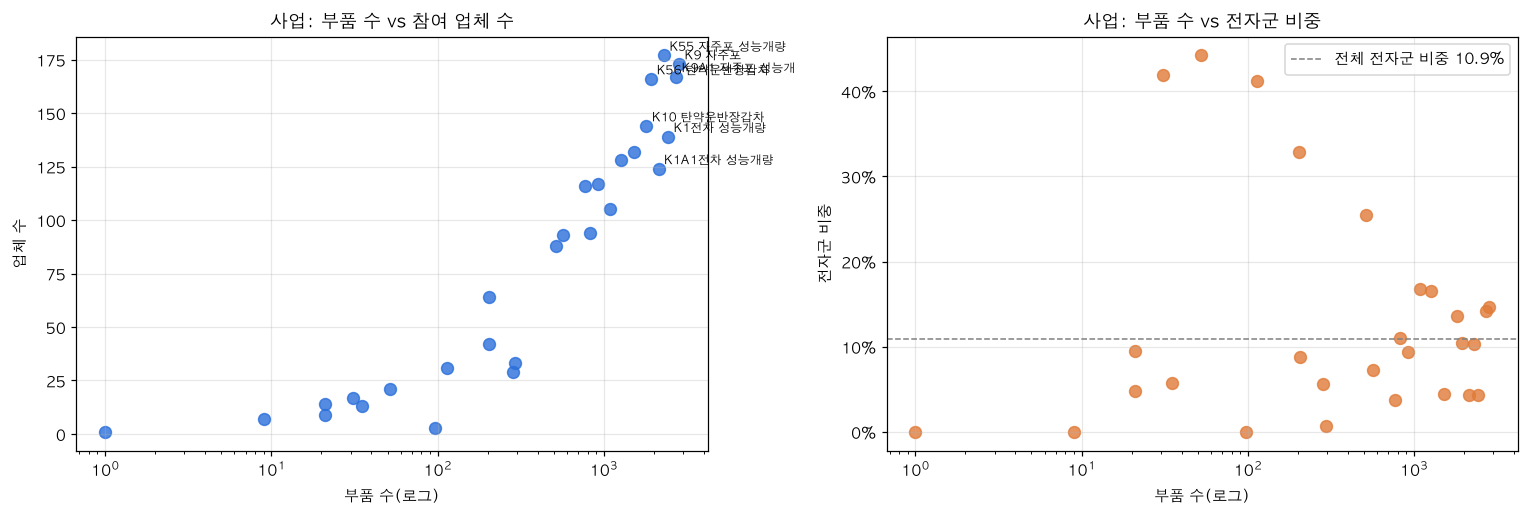

,부품수,업체수,FSC4종수,전자군수,전자군비중
사업명,,,,,
K9 자주포,"2,838",173,149,417,14.7%
K9A1 자주포 성능개량,"2,726",167,144,388,14.2%
K1전차 성능개량,"2,439",139,122,105,4.3%
K55 자주포 성능개량,"2,304",177,149,239,10.4%
K1A1전차 성능개량,"2,136",124,111,93,4.4%
K56 탄약운반장갑차,"1,931",166,131,201,10.4%
K10 탄약운반장갑차,"1,807",144,128,245,13.6%
보병탑승차량,"1,514",132,99,67,4.4%
경구난차량,"1,269",128,126,210,16.5%


In [12]:
proj = b2.groupby("사업명").agg(
    부품수=("부품관리번호", "count"),
    업체수=("업체_정규", "nunique"),
    FSC4종수=("fsc4", "nunique"),
    전자군수=("전자군", "sum"),
).assign(전자군비중=lambda x: x.전자군수 / x.부품수)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].scatter(proj.부품수, proj.업체수, s=60, color=C_MAIN, alpha=.8)
for n, r in proj.iterrows():
    if r.부품수 > proj.부품수.quantile(.8) or r.업체수 > proj.업체수.quantile(.85):
        ax[0].annotate(n[:12], (r.부품수, r.업체수), fontsize=8, xytext=(4, 3), textcoords="offset points")
ax[0].set(xscale="log", title="사업: 부품 수 vs 참여 업체 수", xlabel="부품 수(로그)", ylabel="업체 수")
ax[0].grid(alpha=.3)

ax[1].scatter(proj.부품수, proj.전자군비중, s=60, color=C_SUB, alpha=.8)
ax[1].axhline(b2.전자군.mean(), ls="--", color="grey", lw=1, label=f"전체 전자군 비중 {b2.전자군.mean():.1%}")
ax[1].set(xscale="log", title="사업: 부품 수 vs 전자군 비중", xlabel="부품 수(로그)", ylabel="전자군 비중")
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

proj.sort_values("부품수", ascending=False).style.format(
    {"부품수": "{:,}", "업체수": "{:,}", "FSC4종수": "{:,}", "전자군수": "{:,}", "전자군비중": "{:.1%}"})

## 8. 공간 — 업체 소재 시도 (연결 결과와 연결률을 함께 보고)

이 데이터에는 위치 열이 **없다**. 업체명을 정제본의 업체 대장(`clean_company` — 사업자번호·시도)에 이어 붙여야 시도 축이 생긴다. 연결은 RDS `clean_company_name_link`(`source='localized_item'`, `match_type` = exact / multi / none)로만 하고 **연결률·미연결·다중 일치를 함께 보고한다**(`data-cleaning-rules.md` §3).

RDS에 닿지 않는 망에서는 이 절만 건너뛴다(저장된 출력은 RDS 에 접속해 실행한 결과).

In [13]:
import sys as _sys
_sys.path.insert(0, str(ROOT / "scripts"))
link_rate = sido = None

# 업체명 정규화는 정제본(clean_dapa_localized_item.contractor_name_norm)이 기준이다.
# 노트북에서 키를 다시 만들면 규칙이 갈라지므로 연결은 DB 안에서 한다.
# 연결표는 name_norm 이 4건 중복돼 있다(반석기공 · 킴블스 = exact 2건씩 / 대성정밀 · 한화디펜스 = none 2건씩)
# → 이름 단위로 한 줄로 줄여야 부품 행이 증식하지 않는다(줄인 뒤 LEFT JOIN 결과가 25,025행).
LINK = """(SELECT name_norm, MIN(biz_reg_no) AS biz_reg_no, MIN(match_type) AS match_type,
                  COUNT(*) AS link_rows
             FROM clean_company_name_link
            WHERE source = 'localized_item'
            GROUP BY name_norm)"""
try:
    import dbconf, pymysql
    kw = dbconf.pymysql_kwargs("etl"); kw["connect_timeout"] = 30
    cn = pymysql.connect(**kw)
    with cn.cursor() as c:
        c.execute(f"""SELECT COALESCE(l.match_type, '(연결표에 없음)') AS match_type, COUNT(*) AS parts
                        FROM clean_dapa_localized_item b
                        LEFT JOIN {LINK} l ON l.name_norm = b.contractor_name_norm
                       GROUP BY 1 ORDER BY parts DESC""")
        link_rate = pd.DataFrame(c.fetchall(), columns=["연결 유형", "부품 행"])

        # ref_sido_map 은 token → 코드 조회표(44 토큰 / 17 시도)라 코드로 바로 조인하면 행이 증식한다 → DISTINCT
        c.execute(f"""SELECT s.sido_code, s.sido_name, COUNT(*) AS parts
                        FROM clean_dapa_localized_item b
                        JOIN {LINK} l ON l.name_norm = b.contractor_name_norm AND l.match_type = 'exact'
                        JOIN clean_company cc ON cc.biz_reg_no = l.biz_reg_no
                        JOIN (SELECT DISTINCT sido_code, sido_name FROM ref_sido_map) s
                             ON s.sido_code = cc.sido_code
                       GROUP BY s.sido_code, s.sido_name ORDER BY parts DESC""")
        sido = pd.DataFrame(c.fetchall(), columns=["sido_code", "sido_name", "부품수"])
    cn.close()
    print(f"RDS 조회 완료 — 연결 유형 {len(link_rate)}종 · 시도 {len(sido)}개")
except Exception as e:
    print(f"RDS 접속 불가 → 8절 건너뜀 ({type(e).__name__}: {e}). 허용된 망에서 다시 실행한다.")

RDS 조회 완료 — 연결 유형 4종 · 시도 13개


In [14]:
if link_rate is not None:
    tot = int(link_rate["부품 행"].sum())
    lr = link_rate.assign(비율=lambda x: x["부품 행"] / tot)
    print(f"업체명 연결 결과 — 부품 행 기준 합계 {tot:,} (정제본 25,025행과 같아야 한다: "
          f"{'일치' if tot == 25025 else '불일치'})")
    display(lr.style.format({"부품 행": "{:,}", "비율": "{:.1%}"}).hide(axis="index"))

    if sido is not None and len(sido):
        n_sido = int(sido.부품수.sum())
        print(f"\nexact 연결 중 시도까지 확인된 부품 {n_sido:,}행 "
              f"({n_sido / tot:.1%}) · {len(sido)}개 시도. "
              "나머지는 미연결(none) · 다중 일치(multi) · 연결표 미등재이며 채우지 않는다.")
        display(sido.style.format({"부품수": "{:,}"}).hide(axis="index"))

업체명 연결 결과 — 부품 행 기준 합계 25,025 (정제본 25,025행과 같아야 한다: 일치)


연결 유형,부품 행,비율
exact,"15,388",61.5%
none,"8,408",33.6%
(연결표에 없음),636,2.5%
multi,593,2.4%



exact 연결 중 시도까지 확인된 부품 15,388행 (61.5%) · 13개 시도. 나머지는 미연결(none) · 다중 일치(multi) · 연결표 미등재이며 채우지 않는다.


sido_code,sido_name,부품수
48,경상남도,"8,327"
41,경기도,"2,647"
26,부산광역시,"1,973"
44,충청남도,"1,290"
11,서울특별시,526
28,인천광역시,396
47,경상북도,88
43,충청북도,59
52,전북특별자치도,40
27,대구광역시,14


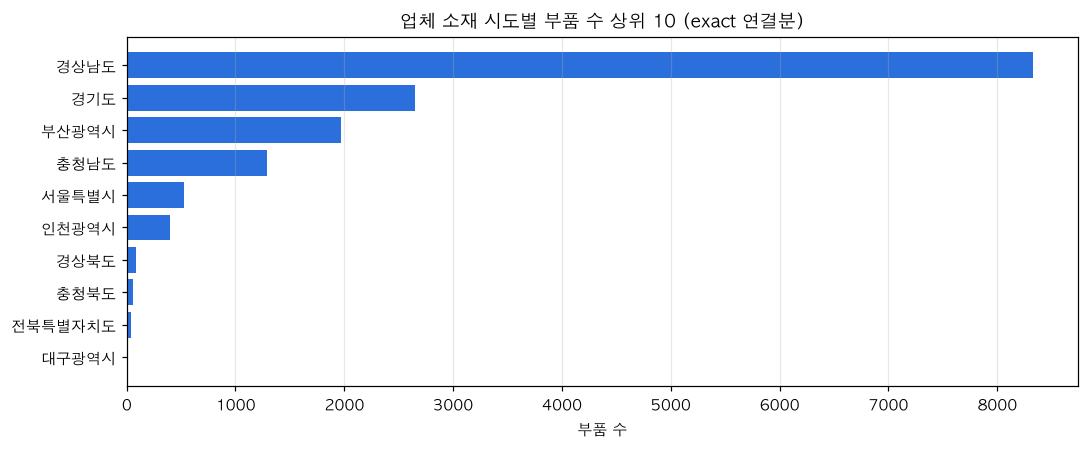

In [15]:
if sido is not None and len(sido):
    import json as _json
    import plotly.express as px
    gj = _json.loads((REF / "sido_boundary.geojson").read_text(encoding="utf-8"))
    s = sido.dropna(subset=["sido_code"]).copy()
    share = s.부품수.sum() / len(b2)
    fig = px.choropleth(s, geojson=gj, locations="sido_code", featureidkey="id", color="부품수",
                        hover_name="sido_name", color_continuous_scale="Blues",
                        title=(f"업체 소재 시도별 국산화개발품목 수 — 업체명 exact 연결분만 "
                               f"({int(s.부품수.sum()):,}행 · 전체의 {share:.0%}). 소재지는 개발 · 생산지가 아니다"))
    fig.update_geos(fitbounds="locations", visible=False)
    fig.update_layout(height=520, margin=dict(l=0, r=0, t=60, b=0))
    fig.show()

    t = s.nlargest(10, "부품수")[::-1]
    fig2, ax = plt.subplots(figsize=(10, 4.2))
    ax.barh(t.sido_name.fillna("(미확인)"), t.부품수, color=C_MAIN)
    ax.set(title="업체 소재 시도별 부품 수 상위 10 (exact 연결분)", xlabel="부품 수")
    ax.grid(axis="x", alpha=.3); plt.tight_layout(); plt.show()

## 9. 차이검정

> **보조 분석 — 결론 · 발표 · 화면에는 쓰지 않는다.** 표본이 사업 28개로 작고 분포가 치우쳐 있어 검정 결과는 경향을 확인하는 참고로 읽는다. 결론은 해석이 분명한 비율 · 순위를 쓴다.

표본이 사업 28개 · 업체 수백 개로 작고 분포가 치우쳐 있어 **비모수**를 기본으로 한다. 유의수준 α = 0.05, 검정 3개이므로 Bonferroni 기준 0.017도 함께 적는다.

| 가설 | 내용 |
|---|---|
| H1 | 전자 계열 부품 비중은 사업마다 다르다 (사업 × 전자군 여부 독립성) |
| H2 | 같은 사업 안에서 전자 계열 부품 수는 비전자 부품 수와 다르다 (대응 비교) |
| H3 | 전자 계열 부품을 다루는 업체는 그렇지 않은 업체보다 담당 부품 수가 많다 |

In [16]:
rows = []

# H1 — 카이제곱 독립성 + Cramer's V
ct = pd.crosstab(b2.사업명, b2.전자군)
chi2, p1, dof, exp = stats.chi2_contingency(ct)
v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
rows.append(["H1 사업 × 전자군 여부", f"{ct.shape[0]}×{ct.shape[1]}", "카이제곱 독립성",
             f"{chi2:,.1f} (dof {dof})", p1, f"Cramer's V={v:.3f}",
             f"기대빈도 5 미만 셀 {int((exp < 5).sum())}개"])

# H2 — 사업 단위 대응 비교. 차이의 정규성을 먼저 보고 Wilcoxon / 대응 t 를 고른다
a = piv["전자군"].astype(float)
b = piv["비전자"].astype(float)
sh_p = stats.shapiro(a - b).pvalue
if sh_p < .05:
    st2, p2 = stats.wilcoxon(a, b); name2 = "Wilcoxon 부호순위"
else:
    st2, p2 = stats.ttest_rel(a, b); name2 = "대응 t"
z = stats.norm.isf(min(p2 / 2, 0.4999))
rows.append(["H2 사업당 전자군 vs 비전자 부품 수", f"n={len(a)}", name2, f"{st2:,.2f}", p2,
             f"r={z / np.sqrt(len(a)):+.2f}",
             f"정규성 p={sh_p:.4f} · 중앙값 {a.median():,.0f} vs {b.median():,.0f}"])

# H3 — 업체 단위 Mann-Whitney
cw = b2.groupby("업체_정규").agg(부품수=("부품관리번호", "count"), 전자있음=("전자군", "any"))
g1 = cw[cw.전자있음].부품수.values
g0 = cw[~cw.전자있음].부품수.values
u, p3 = stats.mannwhitneyu(g1, g0, alternative="two-sided")
r3 = 2 * u / (len(g1) * len(g0)) - 1          # 순위이연 상관 (rank-biserial)
rows.append(["H3 업체 담당 부품 수 — 전자 취급 vs 미취급", f"{len(g1)} vs {len(g0)}", "Mann-Whitney U",
             f"{u:,.0f}", p3, f"r={r3:+.2f}",
             f"중앙값 {np.median(g1):,.0f} vs {np.median(g0):,.0f}"])

t9 = pd.DataFrame(rows, columns=["가설", "표본", "검정", "통계량", "p값", "효과크기", "비고"])
t9["판정(α=.05)"] = np.where(t9.p값 < .05, "유의", "유의하지 않음")
t9["Bonferroni(.017)"] = np.where(t9.p값 < .017, "유의", "유의하지 않음")
t9.style.format({"p값": "{:.4g}"}).hide(axis="index")

가설,표본,검정,통계량,p값,효과크기,비고,판정(α=.05),Bonferroni(.017)
H1 사업 × 전자군 여부,28×2,카이제곱 독립성,958.4 (dof 27),1.478e-184,Cramer's V=0.196,기대빈도 5 미만 셀 7개,유의,유의
H2 사업당 전자군 vs 비전자 부품 수,n=28,Wilcoxon 부호순위,0.00,3.787e-06,r=+0.87,정규성 p=0.0004 · 중앙값 57 vs 456,유의,유의
H3 업체 담당 부품 수 — 전자 취급 vs 미취급,98 vs 306,Mann-Whitney U,"21,694",2.187e-11,r=+0.45,중앙값 28 vs 4,유의,유의


## 10. 상관분석

> **보조 분석 — 결론 · 발표 · 화면에는 쓰지 않는다.** 표본이 사업 28개로 작고 분포가 치우쳐 있어 검정 결과는 경향을 확인하는 참고로 읽는다. 결론은 해석이 분명한 비율 · 순위를 쓴다.

사업 28개를 표본으로 지표 사이의 **Spearman 순위상관**을 본다. 유의 기준 |ρ|는 표본 수에서 직접 계산해 출력한다.

n = 28 → 유의 기준 |rho| >= 0.374


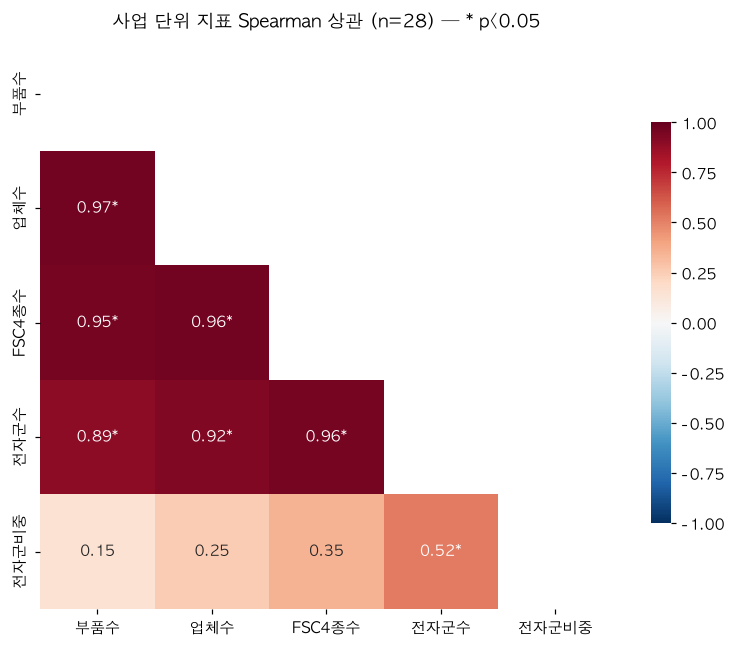

,,rho,p
부품수,업체수,+0.97,0.0000
업체수,FSC4종수,+0.96,0.0000
FSC4종수,전자군수,+0.96,0.0000
부품수,FSC4종수,+0.95,0.0000
업체수,전자군수,+0.92,0.0000
부품수,전자군수,+0.89,0.0000
전자군수,전자군비중,+0.52,0.0049


In [17]:
crit_t = stats.t.ppf(.975, len(proj) - 2)
crit = crit_t / np.sqrt(len(proj) - 2 + crit_t ** 2)
print(f"n = {len(proj)} → 유의 기준 |rho| >= {crit:.3f}")

feat = proj[["부품수", "업체수", "FSC4종수", "전자군수", "전자군비중"]].copy()
rho, pv = stats.spearmanr(feat)
rho = pd.DataFrame(rho, index=feat.columns, columns=feat.columns)
pv = pd.DataFrame(pv, index=feat.columns, columns=feat.columns)
annot = rho.round(2).astype(str) + np.where(pv < .05, "*", "")
mask = np.triu(np.ones_like(rho, bool))

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(rho, mask=mask, annot=annot, fmt="", cmap="RdBu_r", vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": .7}, ax=ax)
ax.set_title(f"사업 단위 지표 Spearman 상관 (n={len(proj)}) — * p<0.05")
plt.tight_layout(); plt.show()

pairs = (rho.where(~np.tril(np.ones_like(rho, bool))).stack().rename("rho").to_frame()
           .join(pv.stack().rename("p")).dropna(subset=["rho"])
           .sort_values("rho", key=abs, ascending=False))
pairs[pairs.p < .05].style.format({"rho": "{:+.2f}", "p": "{:.4f}"})

## 11. 요약·한계

### 발견 (모두 위 셀의 실행 결과, 원본 + RDS 정제본)

| # | 구분 | 내용 |
|---|---|---|
| 1 | 점검 | 원본 33,965 → 업무키 고유 25,025(완전 중복 8,940, **업무키 충돌 0**) → FSC 4자리 유효 25,009 → 전자 계열 2,717(8.0%) → 반도체군 67. 정제본 `clean_dapa_localized_item`의 25,025행·전자군 2,717행과 **일치**한다 |
| 2 | 점검 | FSC가 4자리가 아닌 행 16개(값 `0` 15건 + 결측 1건)는 군급 축에서 제외하고 남겼다. 같은 부품이 여러 사업에 중복 등재된 정도는 최대 57회이며(중복 1회뿐인 부품 20,703개), 그래서 **원본 33,965와 고유 25,025는 다른 숫자**다 |
| 3 | 기술통계 | 세 단위 모두 꼬리가 길다. 사업 28개는 비교적 고르지만(평균 894 · 중앙값 542 · 최대 2,838 · 왜도 0.78 · 상위 5개 49.7%), 군급 FSC4 242종(중앙값 12.5 · 왜도 6.56)과 업체 404개(중앙값 6 · 최대 2,676 · 왜도 7.51 · 상위 5개 40.3%)는 극단적으로 치우쳐 있다 → 비모수 검정을 쓴다 |
| 4 | 추세(없음) | `최종수정일`은 6,865행(27.4%)만 있고 **전부 2021년**이다(결측 18,160). 연도 축 비교가 불가능하므로 이 데이터에는 시간 추세가 없다. 게다가 채움률이 전자군 17.4% vs 비전자 28.7%로 **결측이 전자군에 더 쏠려 있어** 부분 집합으로 추세를 대신하는 것도 부적절하다 |
| 5 | 비교 | 부품이 가장 많은 사업은 K9 자주포 2,838 · K9A1 자주포 성능개량 2,726 · K1전차 성능개량 2,439다. 전자 비중은 사업 규모와 반대로 움직인다 — 규모 하위권인 한국형기동헬기 후속 44.2% · 의무 후송 전용 헬기 41.9% · 화생방정찰차 41.2% · 230mm급 다련장 32.8%가 가장 높고, 81mm 박격포 0.7%와 경기관총 등 0% 사업 3개가 가장 낮다 |
| 6 | 구성 | 군급 편중이 이 데이터의 핵심 메시지다. FSG 53(철물·연마재) 10,368 · 25(차량 장비 부품) 3,037 · **59(전기·전자 부품) 2,380** · 47(배관·호스) 2,106 순이고, 전자 계열은 59와 58(통신·탐지·방사) 337 둘뿐이며 **60(광섬유·전기)은 0행**이다 |
| 7 | 구성 | **반도체군(FSC 5961·5962)은 업무키 고유 67행 · 원본 기준 83행뿐**이다(10개 사업 · 22개 업체). 「반도체군 국산화 근거는 거의 없다」는 결론의 근거이며, **근거 없음이 아니라 근거 있는 빈칸**으로 읽는다 |
| 8 | 공간 | 위치 열이 없어 업체명을 업체 대장에 이어 붙였다. 연결 결과는 exact 15,388행(61.5%) · 미연결 8,408(33.6%) · 다중 일치 593(2.4%) · 연결표 미등재 636(2.5%)이고 합계가 정제본 25,025와 같다. exact 연결분의 시도는 **경상남도 8,327(54.1%) · 경기도 2,647 · 부산광역시 1,973 · 충청남도 1,290** 순으로 13개 시도다 |
| 9 | 차이검정 | 세 가설 모두 α=0.05와 Bonferroni 0.017에서 **유의**하다. H1 사업마다 전자 비중이 다르다(카이제곱 χ²=958.4, dof 27, p<1e-183, Cramér's V=0.196 — 유의하지만 연관 강도는 작다). H2 **같은 사업 안에서 전자 부품은 비전자 부품보다 적다**(Wilcoxon W=0, p=3.8e-06, r=+0.87, 중앙값 57 vs 456 — 28개 사업 **전부** 같은 방향). H3 전자 부품을 다루는 업체가 담당 부품 수가 많다(Mann-Whitney U=21,694, p=2.2e-11, r=+0.45, 중앙값 28 vs 4) |
| 10 | 상관 | 사업 단위 규모 지표들이 서로 거의 같은 정보다 — 부품수 × 업체수 ρ=+0.97, 업체수 × FSC4종수 +0.96, FSC4종수 × 전자군수 +0.96, 부품수 × FSC4종수 +0.95. 사실상 「사업 규모」 한 축이므로 **화면에는 하나만 둔다**. 반면 **전자군 비중은 사업 규모와 유의한 상관이 없다**(n=28 유의 기준 |ρ| ≥ 0.374) — 전자 비중은 규모가 아니라 무기체계 성격의 문제다 |

### 한계·주의

- **건수는 국산화율이 아니다.** 분모(해당 사업의 전체 부품 수)가 이 데이터에 없으므로 「율」·「자립도」를 계산하지 않았고 하지 않는다.
- **28개 사업(대부분 지상 장비, 함정 · 유도 없음)의 2023-08 등록 목록(기준일 미표기)**이다. 헬기 · 해상초계기 사업은 일부만 들어 있어(한국형기동헬기 후속 52행 등) 「우리 군 전체」로 일반화할 수 없다.
- 규모는 항상 **원본 33,965 / 업무키 고유 25,025 / 부품관리번호 고유 12,788**을 나란히 쓴다. 발견 2의 중복 분포가 그 이유다.
- 업체 소재지는 **사업자등록 주소**이며 개발지·생산지가 아니다. 미연결 33.6%는 채우지 않았고, 연결률을 빼고 시도 분포만 보여 주지 않는다.
- 업체명 정규화는 **정제본(`contractor_name_norm`, 403개)이 기준**이다. 이 노트북의 간단 규칙은 404개로 1개 차이가 나므로 §3·§7의 업체 단위 수치는 ±1 업체 오차를 안고 있다. 공간 절(§8)은 그래서 노트북에서 키를 만들지 않고 DB 안에서 연결했다.
- H1 카이제곱은 기대빈도 5 미만 셀이 7개여서 근사가 완벽하지 않다. 또 세 검정 모두 관측 단위가 **부품 행**인데 같은 사업·같은 업체의 부품은 서로 독립이 아니다 → p값이 실제보다 작게 나오기 쉽다. **탐색 단계 결과**로 읽고 효과크기를 함께 본다.
- 군급분류(FSC)는 이 노트북 안에서만 쓰는 축이다. **관세청 HS와는 어떤 수준에서도 연결·합산하지 않는다**(HS ↔ FSC 카테고리 맵을 쓰지 않는다).
- §8은 RDS 조회가 필요하다. 접속이 안 되는 망에서는 그 절만 건너뛰며, 저장된 출력은 RDS 에 접속해 실행한 결과다.
